In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
%cd "/content/drive/MyDrive/Dataset"
!ls

/content/drive/MyDrive/Dataset
UNSW_NB15_testing-set.csv  UNSW_NB15_training-set.csv


In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay

In [4]:
def load_data(file_path):
  data = pd.read_csv(file_path)
  return data

train_df = load_data("/content/drive/MyDrive/Dataset/UNSW_NB15_training-set.csv")
test_df = load_data("/content/drive/MyDrive/Dataset/UNSW_NB15_testing-set.csv")

def preprocess(train_df, test_df):
  excluded_cols = ["id", "label", "attack_cat"]

  train_features = train_df.drop(columns=excluded_cols)
  test_features = test_df.drop(columns=excluded_cols)

  categorical_cols = train_features.select_dtypes(include=["object"]).columns.tolist()

  train_labels_text = train_df["attack_cat"]
  test_labels_text = test_df["attack_cat"]

  label_encoder = LabelEncoder()
  train_labels = label_encoder.fit_transform(train_labels_text)
  test_labels = label_encoder.transform(test_labels_text)

  train_features_encoded = pd.get_dummies(train_features, columns=categorical_cols)
  test_features_encoded = pd.get_dummies(test_features, columns=categorical_cols)

  train_features_encoded, test_features_encoded = train_features_encoded.align(
      test_features_encoded,
      join="left",
      axis=1,
      fill_value=0
  )

  train_features_encoded = train_features_encoded.astype(float)
  test_features_encoded = test_features_encoded.astype(float)

  scaler = StandardScaler()
  train_features_scaled = scaler.fit_transform(train_features_encoded)
  test_features_scaled = scaler.transform(test_features_encoded)

  return train_features_scaled, train_labels, test_features_scaled, test_labels, label_encoder

attack_cat
Normal            37000
Generic           18871
Exploits          11132
Fuzzers            6062
DoS                4089
Reconnaissance     3496
Analysis            677
Backdoor            583
Shellcode           378
Worms                44
Name: count, dtype: int64
attack_cat
Normal            56000
Generic           40000
Exploits          33393
Fuzzers           18184
DoS               12264
Reconnaissance    10491
Analysis           2000
Backdoor           1746
Shellcode          1133
Worms               130
Name: count, dtype: int64


82332
attack_cat
Normal            37000
Generic           18871
Exploits          11132
Fuzzers            6062
DoS                4089
Reconnaissance     3496
Analysis            677
Backdoor            583
Shellcode           378
Worms                44
Name: count, dtype: int64


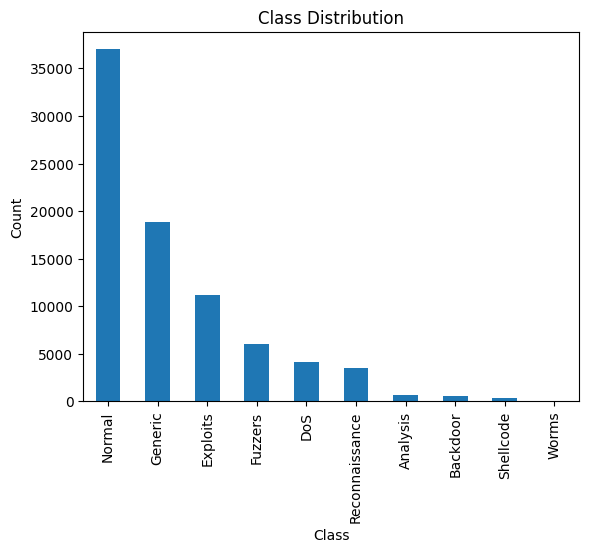

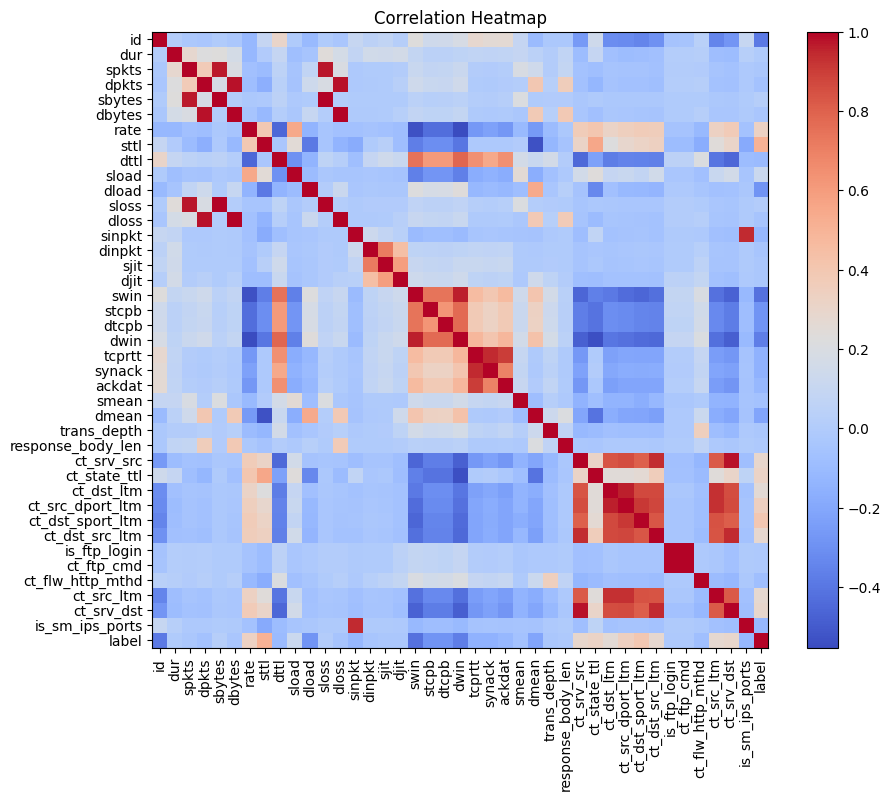

In [28]:
def dataset_info(df):
  print(len(df))
  print(df["attack_cat"].value_counts())

  df["attack_cat"].value_counts().plot(kind="bar")
  plt.title("Class Distribution")
  plt.xlabel("Class")
  plt.ylabel("Count")

  numeric_df = df.select_dtypes(include=np.number)
  corr_matrix = numeric_df.corr()
  plt.figure(figsize=(10, 8))
  plt.imshow(corr_matrix, cmap="coolwarm", interpolation="nearest", )
  plt.colorbar()
  plt.title("Correlation Heatmap")
  plt.xticks(range(len(corr_matrix.columns)), corr_matrix.columns, rotation=90)
  plt.yticks(range(len(corr_matrix.columns)), corr_matrix.columns)

  plt.show()


dataset_info(train_df)

In [5]:
def calculate_class_weights(train_labels):
  classes = np.unique(train_labels)

  class_weights = compute_class_weight(
      class_weight="balanced",
      classes=classes,
      y=train_labels
  )

  class_weights = np.sqrt(class_weights)

  class_weights_dict = dict(zip(classes, class_weights))

  return class_weights_dict

In [6]:
def create_validation_split(train_features_scaled, train_labels):
  return train_test_split(
      train_features_scaled,
      train_labels,
      test_size=0.2,
      random_state=42,
      stratify=train_labels
  )

In [16]:
def build_model(input_dim, num_classes):
  model = Sequential([
      Dense(64, activation="relu", input_shape=(input_dim,)),
      Dense(32, activation="relu"),
      Dense(16, activation="relu"),
      Dense(num_classes, activation="softmax")
  ])

  model.compile(
      optimizer="adam",
      loss="sparse_categorical_crossentropy",
      metrics=["acc"]
  )

  model.summary()

  return model

In [8]:
def train_model(model, train_features_final, train_labels_final, validation_features, validation_labels, class_weights_dict):
  history = model.fit(
      train_features_final,
      train_labels_final,
      epochs=10,
      batch_size=64,
      validation_data=(validation_features, validation_labels),
      class_weight=class_weights_dict
  )

  return history

In [17]:
def evaluate_model(history, model, test_features_scaled, test_labels):
  acc_train = history.history["acc"]
  loss_train = history.history["loss"]
  acc_val = history.history["val_acc"]
  loss_val = history.history["val_loss"]

  epochs = range(1, len(acc_train) + 1)

  plt.figure()
  plt.ylim(bottom=0)
  plt.plot(epochs, acc_train, "o-", color="blue", label="Train accuracy")
  plt.plot(epochs, acc_val, "s--", color="red", label="Val accuracy")
  plt.title("Train vs Validation Accuracy")
  plt.xlabel("Epoch")
  plt.ylabel("Accuracy")
  plt.legend()

  plt.figure()
  plt.ylim(bottom=0)
  plt.plot(epochs, loss_train, "o-", color="blue", label="Train loss")
  plt.plot(epochs, loss_val, "s--", color="red", label="Val loss")
  plt.title("Train vs Validation Loss")
  plt.xlabel("Epoch")
  plt.ylabel("Loss")
  plt.legend()

  plt.show()

  test_loss, test_accuracy = model.evaluate(test_features_scaled, test_labels)

  print("Test accuracy:", test_accuracy)
  print("Test loss:", test_loss)

In [31]:
def predict(model, test_features_scaled):
  predictions = model.predict(test_features_scaled)
  return predictions

def evaluate_predictions(predictions, test_labels, label_encoder):
  label_pred = np.argmax(predictions, axis=1)
  label_true = test_labels

  print("Classification Report:")
  print(classification_report(
      label_true,
      label_pred,
      target_names=label_encoder.classes_
  ))

  cm = confusion_matrix(label_true, label_pred)

  disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Analysis', 'Backdoor', 'DoS', 'Exploits', 'Fuzzers', 'Generic', 'Normal',
 'Reconnaissance', 'Shellcode', 'Worms'])

  disp.plot(cmap=plt.cm.Reds, xticks_rotation=90)
  plt.title("Confusion Matrix")
  plt.show()

In [14]:
def run_experiment(train_df, test_df):
  train_features_scaled, train_labels, test_features_scaled, test_labels, label_encoder = preprocess(train_df, test_df)
  train_features_final, validation_features, train_labels_final, validation_labels = create_validation_split(train_features_scaled, train_labels)
  class_weights_dict = calculate_class_weights(train_labels_final)

  input_dim = train_features_scaled.shape[1]
  num_classes = len(label_encoder.classes_)
  model = build_model(input_dim, num_classes)

  history = train_model(model, train_features_final, train_labels_final, validation_features, validation_labels, class_weights_dict)
  evaluate_model(history, model, test_features_scaled, test_labels)
  predictions = predict(model, test_features_scaled)
  evaluate_predictions(predictions, test_labels, label_encoder)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_12 (Dense)                │ (None, 64)             │        12,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 10)             │           170 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,002 (58.60 KB)

 Trainable params: 15,002 (58.60 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
1030/1030 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - acc: 0.7318 - loss: 0.9070 - val_acc: 0.7563 - val_loss: 0.6314
Epoch 2/10
1030/1030 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - acc: 0.8009 - loss: 0.6689 - val_acc: 0.8124 - val_loss: 0.5450
Epoch 3/10
1030/1030 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - acc: 0.8145 - loss: 0.6245 - val_acc: 0.8249 - val_loss: 0.5046
Epoch 4/10
1030/1030 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - acc: 0.8208 - loss: 0.5999 - val_acc: 0.8113 - val_loss: 0.5254
Epoch 5/10
1030/1030 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - acc: 0.8244 - loss: 0.5813 - val_acc: 0.8232 - val_loss: 0.4917
Epoch 6/10
1030/1030 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - acc: 0.8278 - loss: 0.5663 - val_acc: 0.8057 - val_loss: 0.5306
Epoch 7/10
1030/1030 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - acc: 0.8298 - loss: 0.5551 - val_acc: 0.8173 - val_loss: 0.5090
Epoch 8/10
1030/1030 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - acc: 0.8325 - loss: 0.5462 - val_acc: 0.8284 - val_loss: 0.4759
Epoch 9/10
1030/1030 ━━━━━━━━━━━━━━━━━━━

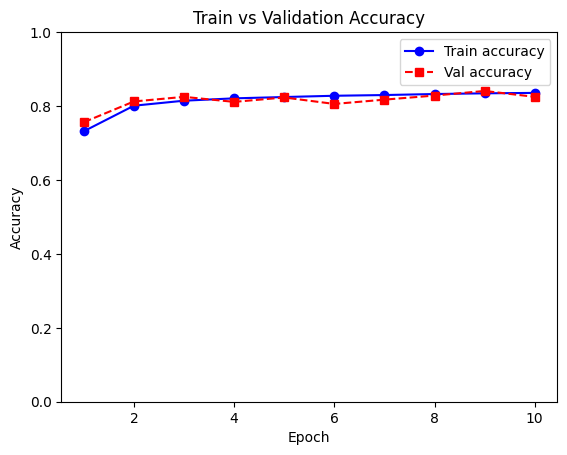

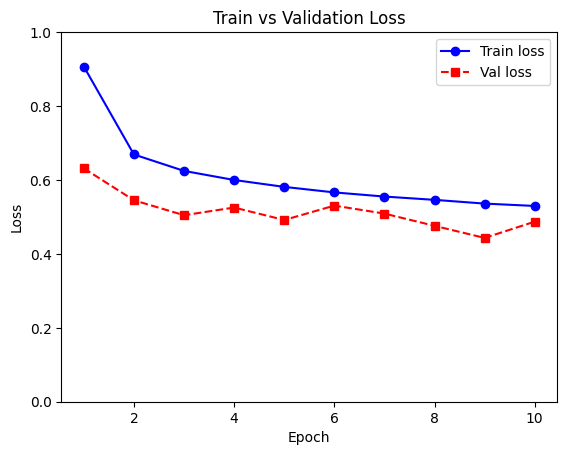

5480/5480 ━━━━━━━━━━━━━━━━━━━━ 10s 2ms/step - acc: 0.7482 - loss: 0.7300
Test accuracy: 0.7482391595840454
Test loss: 0.7299875617027283
5480/5480 ━━━━━━━━━━━━━━━━━━━━ 9s 2ms/step
Classification Report:
                precision    recall  f1-score   support

      Analysis       0.05      0.01      0.02      2000
      Backdoor       0.03      0.00      0.00      1746
           DoS       0.33      0.80      0.47     12264
      Exploits       0.80      0.51      0.62     33393
       Fuzzers       0.62      0.23      0.34     18184
       Generic       0.99      0.98      0.99     40000
        Normal       0.81      0.95      0.87     56000
Reconnaissance       0.74      0.67      0.71     10491
     Shellcode       0.29      0.50      0.37      1133
         Worms       0.12      0.17      0.14       130

      accuracy                           0.75    175341
     macro avg       0.48      0.48      0.45    175341
  weighted avg       0.77      0.75      0.74    175341



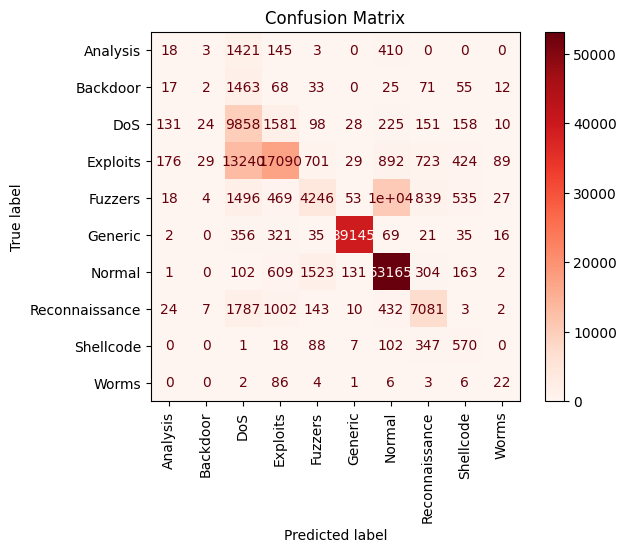

In [32]:
run_experiment(train_df, test_df)